# Go/No-Go 2 executable-baseline results

## tl;dr

- Direct LLM generated valid outputs for **6/10** cases; the CADIR/SimpleCADAPI
  SDK-conditioned baseline generated **9/10**.
- Neither method passed geometry, assembly, and kinematics simultaneously on
  any case (**0/10** for both).
- The frozen four-method decision remains **INCONCLUSIVE**, because ArtiCAD and
  AssemCAD are `NOT_RUN` rather than measured failures.

## Context & Methods

Both executable methods use the same fixed 10-case dataset, six views, text
prompt, `qwen3.7-plus`, and deterministic evaluation. Direct LLM receives one
call per case. The SDK-conditioned method may make at most three calls and gets
only schema/CAD-execution errors for repair.

This is not a full reproduction of the CADIR paper: its public repository
provides SimpleCADAPI and agent-facing documentation, but not the reported
five-agent orchestrator or learned retrieval components. Metric medians below
are calculated only over successfully generated outputs; failed generations
remain explicit and are never imputed as numeric zeroes.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if root.name == "notebooks":
    root = root.parents[1]
results_dir = root / "go_nogo2" / "results"
aggregate = pd.read_csv(results_dir / "aggregate_results.csv")
status = pd.read_csv(results_dir / "run_status.csv")
failures = pd.read_csv(results_dir / "failure_breakdown.csv")
summary = json.loads((results_dir / "summary.json").read_text(encoding="utf-8"))

## Data validation

The assertions enforce the frozen denominator and make the distinction between
terminal results and `NOT_RUN` records explicit.

In [2]:
expected_methods = {
    "direct_frontier_mllm", "cadir_simplecad", "articad", "assemcad"
}
assert len(status) == 40 and set(status.method) == expected_methods
assert status.groupby("method").size().eq(10).all()
assert summary["decision"] == "INCONCLUSIVE"
assert summary["terminal_case_counts"]["direct_frontier_mllm"] == 10
assert summary["terminal_case_counts"]["cadir_simplecad"] == 10
assert summary["not_run_counts"]["articad"] == 10
assert summary["not_run_counts"]["assemcad"] == 10

executed = aggregate.set_index("method").loc[
    ["direct_frontier_mllm", "cadir_simplecad"]
]
assert executed.generation_success_cases.astype(int).tolist() == [6, 9]
assert executed.attempts_total.astype(int).tolist() == [10, 16]
assert executed.simultaneous_success_cases.astype(int).eq(0).all()
executed[["terminal_cases", "generation_success_cases",
          "generation_failure_cases", "attempts_total",
          "simultaneous_success_cases"]]

,terminal_cases,generation_success_cases,generation_failure_cases,attempts_total,simultaneous_success_cases
method,,,,,
direct_frontier_mllm,10,6,4,10,0
cadir_simplecad,10,9,1,16,0


## Results

### Generation success does not imply benchmark success

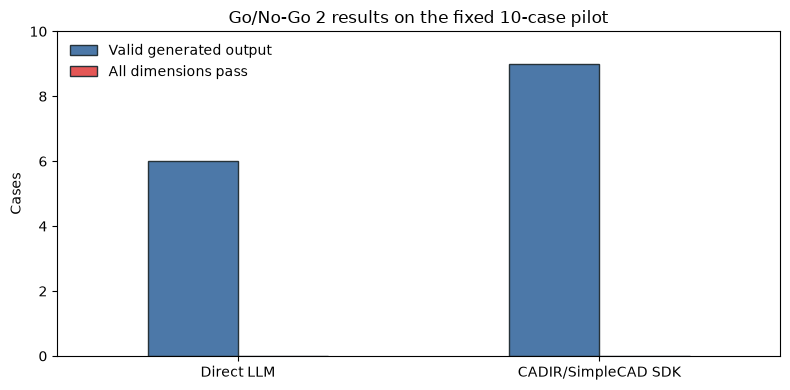

,generation_success_cases,simultaneous_success_cases
Direct LLM,6,0
CADIR/SimpleCAD SDK,9,0


In [3]:
plot_data = executed[["generation_success_cases", "simultaneous_success_cases"]].copy()
plot_data.index = ["Direct LLM", "CADIR/SimpleCAD SDK"]
ax = plot_data.plot.bar(
    color=["#4C78A8", "#E45756"], edgecolor="#263238", figsize=(8, 4)
)
ax.set_title("Go/No-Go 2 results on the fixed 10-case pilot")
ax.set_xlabel("")
ax.set_ylabel("Cases")
ax.set_ylim(0, 10)
ax.tick_params(axis="x", rotation=0)
ax.legend(["Valid generated output", "All dimensions pass"], frameon=False)
plt.tight_layout()
plt.show()
plot_data

### Successful-output metric medians

These conditional medians characterize fidelity only after generation succeeds;
they must be interpreted together with the 6/10 versus 9/10 coverage above.
Lower is better for distance/error columns; higher is better for IoU, F1, and
accuracy columns.

In [4]:
metric_columns = [
    "chamfer_median_successful_outputs",
    "hd95_median_successful_outputs",
    "voxel_iou_median_successful_outputs",
    "part_f1_median_successful_outputs",
    "assembly_graph_f1_median_successful_outputs",
    "joint_type_accuracy_median_successful_outputs",
    "axis_error_degrees_median_median_successful_outputs",
    "joint_origin_error_normalized_median_median_successful_outputs",
    "link_translation_error_normalized_median_median_successful_outputs",
    "link_rotation_error_degrees_median_median_successful_outputs",
]
executed[metric_columns].T.round(4)

method,direct_frontier_mllm,cadir_simplecad
chamfer_median_successful_outputs,0.0050,0.0065
hd95_median_successful_outputs,0.1493,0.1764
voxel_iou_median_successful_outputs,0.3004,0.2988
part_f1_median_successful_outputs,0.7667,0.7000
assembly_graph_f1_median_successful_outputs,0.6667,0.6667
joint_type_accuracy_median_successful_outputs,0.6667,0.6667
axis_error_degrees_median_median_successful_outputs,45.0000,45.0000
joint_origin_error_normalized_median_median_successful_outputs,0.2356,0.1852
link_translation_error_normalized_median_median_successful_outputs,0.3446,0.3093
link_rotation_error_degrees_median_median_successful_outputs,103.2853,92.6648


### Failure patterns

In [5]:
failure_view = failures[
    failures.method.isin(["direct_frontier_mllm", "cadir_simplecad"])
].pivot(index="failure_pattern", columns="method", values="case_count").fillna(0)
failure_view.astype(int).sort_index()

method,cadir_simplecad,direct_frontier_mllm
failure_pattern,,
invalid_cad,1,4
poor_curved_geometry,9,6
poor_geometry,6,6
wrong_joint_axis,5,3
wrong_joint_origin,9,6
wrong_joint_type,7,4
wrong_motion,9,6
wrong_topology,7,4


## Takeaways

1. SDK conditioning plus bounded repair improves valid generation from 6/10 to
   9/10 (30 percentage points), but does not solve output fidelity.
2. The central scientific gap remains visible: neither executable baseline
   succeeds simultaneously on geometry, assembly, and kinematics.
3. The fidelity medians do not show a consistent CADIR advantage over Direct;
   the strongest observed effect is execution robustness.
4. Under frozen protocol v1, no final GO/NO-GO label is permitted until ArtiCAD
   and AssemCAD have comparable terminal runs, or the protocol is prospectively
   amended and re-frozen.